In [ ]:
  import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# **EDA AND DATA PRE PROCESSING**

In [ ]:
df = pd.read_csv("okcupid_profiles.csv")

The Essay questions answer the questions:

essay0- My self summary

essay1- What I’m doing with my life

essay2- I’m really good at

essay3- The first thing people usually notice about me

essay4- Favorite books, movies, show, music, and food

essay5- The six things I could never do without

essay6- I spend a lot of time thinking about

essay7- On a typical Friday night I am

essay8- The most private thing I am willing to admit

essay9- You should message me if...

In [ ]:
df.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay5,essay6,essay7,essay8,essay9,num_essays_present,total_essay_chars,days_since_online,activity_level,norm_activity
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...,10,2467,NaN,NaN,NaN
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN,6,1384,NaN,NaN,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ...",9,5370,4.0,active,0.989189
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,NaN,cats and german philosophy,NaN,NaN,you feel so inclined.,7,440,2.0,active,0.994595
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,NaN,NaN,NaN,NaN,NaN,5,653,NaN,NaN,NaN


# Initial EDA

## Structural checks


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   age                 59946 non-null  int64              
 1   status              59946 non-null  object             
 2   sex                 59946 non-null  object             
 3   orientation         59946 non-null  object             
 4   body_type           54650 non-null  object             
 5   diet                35551 non-null  object             
 6   drinks              56961 non-null  object             
 7   drugs               45866 non-null  object             
 8   education           53318 non-null  object             
 9   ethnicity           54266 non-null  object             
 10  height              59943 non-null  float64            
 11  income              59946 non-null  int64              
 12  job                 51748 non-nu

In [ ]:
missing_summary = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename('missing_pct')
      .to_frame()
)
missing_summary


,missing_pct
norm_activity,59.878891
days_since_online,59.878891
activity_level,59.878891
last_online,59.878891
offspring,59.321723
diet,40.694959
religion,33.740366
pets,33.231575
essay8,32.070530
drugs,23.487806


Convert Inches to CM for ease of interpretation

In [ ]:
df['height'] = df['height']*2.54
df['height'] = df['height'].round(2)

## Descriptive view

In [ ]:
df.columns

Index(['age', 'status', 'sex', 'orientation', 'body_type', 'diet', 'drinks',
       'drugs', 'education', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'location', 'offspring', 'pets', 'religion', 'sign',
       'smokes', 'speaks', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4',
       'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'num_essays_present',
       'total_essay_chars', 'days_since_online', 'activity_level',
       'norm_activity'],
      dtype='object')

In [ ]:
# EDIT THIS FIELD LATER

key_cols = [
    'age', 'status', 'sex', 'orientation', 'body_type', 'diet', 'drinks',
    'drugs', 'education', 'ethnicity', 'height', 'income', 'job',
    'last_online', 'location', 'offspring', 'pets', 'religion',
    'sign', 'smokes', 'speaks'
]

for col in key_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False).head(15))


--- age ---
age
26    3724
27    3685
28    3583
25    3531
29    3295
24    3242
30    3149
31    2735
23    2592
32    2587
33    2206
22    1934
34    1902
35    1755
36    1583
Name: count, dtype: int64

--- status ---
status
single            55697
seeing someone     2064
available          1865
married             310
unknown              10
Name: count, dtype: int64

--- sex ---
sex
m    35829
f    24117
Name: count, dtype: int64

--- orientation ---
orientation
straight    51606
gay          5573
bisexual     2767
Name: count, dtype: int64

--- body_type ---
body_type
average           14652
fit               12711
athletic          11819
NaN                5296
thin               4711
curvy              3924
a little extra     2629
skinny             1777
full figured       1009
overweight          444
jacked              421
used up             355
rather not say      198
Name: count, dtype: int64

--- diet ---
diet
NaN                    24395
mostly anything        16585
a

## Numeric sanity checks

In [ ]:
print(df[['age', 'height', 'income']].describe())

print('Users with age > 80:', (df['age'] > 80).sum())
print('Users with height < 122 cm:', (df['height'] < 122).sum())
print('Users with height > 220 cm:', (df['height'] > 213).sum())
print('Users with income = -1:', (df['income'] == -1).sum())

                age        height          income
count  59946.000000  59943.000000    59946.000000
mean      32.340290   1119.160382    20033.222534
std        9.452779     65.463285    97346.192104
min       18.000000     16.380000       -1.000000
25%       26.000000   1081.560000       -1.000000
50%       30.000000   1114.320000       -1.000000
75%       37.000000   1163.470000       -1.000000
max      110.000000   1556.770000  1000000.000000
Users with age > 80: 2
Users with height < 122 cm: 4
Users with height > 220 cm: 59937
Users with income = -1: 48442


Looking at the data above we can see that most people did not input their income into the profiles, thus, should be removed. Potentially can gather income/class info from essays if have time

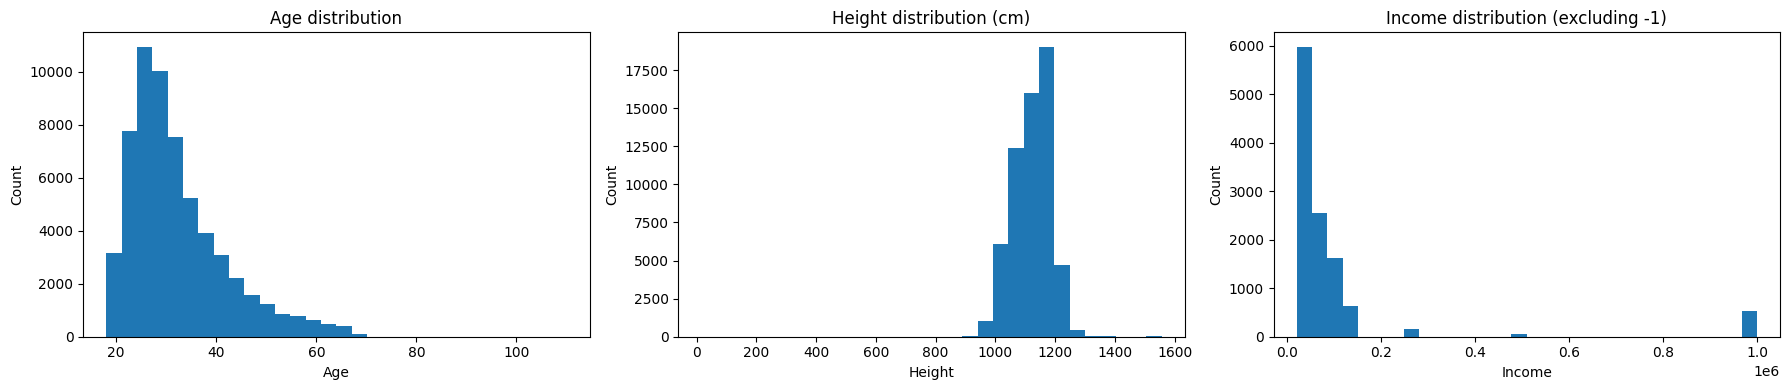

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['age'].dropna(), bins=30)
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].hist(df['height'].dropna(), bins=30)
axes[1].set_title('Height distribution (cm)')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Count')

axes[2].hist(df.loc[df['income'] != -1, 'income'].dropna(), bins=30)
axes[2].set_title('Income distribution (excluding -1)')
axes[2].set_xlabel('Income')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Text columns

In [ ]:
essay_cols = [c for c in df.columns if c.startswith('essay')]

profile_text_summary = pd.DataFrame({
    'non_missing_count': df[essay_cols].notna().sum(),
    'missing_pct': df[essay_cols].isna().mean().mul(100),
    'avg_length_non_missing': [df[c].dropna().str.len().mean() for c in essay_cols]
})

profile_text_summary


,non_missing_count,missing_pct,avg_length_non_missing
essay0,54458,9.154906,634.648536
essay1,52374,12.631368,256.378470
essay2,50308,16.077803,160.238471
essay3,48470,19.143896,88.129503
essay4,49409,17.577486,584.249448
essay5,49096,18.099623,123.235233
essay6,46175,22.972342,142.452669
essay7,47495,20.770360,115.345615
essay8,40721,32.070530,106.059036
essay9,47343,21.023922,189.024861


In [ ]:
df['num_essays_present'] = df[essay_cols].notna().sum(axis=1)
df['total_essay_chars'] = df[essay_cols].fillna('').agg(lambda row: sum(len(x) for x in row), axis=1)

print(df[['num_essays_present', 'total_essay_chars']].describe())


       num_essays_present  total_essay_chars
count        59946.000000       59946.000000
mean             8.104778        2011.203984
std              2.798802        1688.607546
min              0.000000           0.000000
25%              7.000000         892.000000
50%              9.000000        1680.000000
75%             10.000000        2717.000000
max             10.000000       71264.000000


## Cleaning strategy


In [ ]:
df_clean = df.copy()

# 1) Parse date
# The format appears to be YYYY-MM-DD-HH-MM
# Keep both a datetime version and a derived recency signal.
df_clean['last_online_dt'] = pd.to_datetime(
    df_clean['last_online'],
    format='%Y-%m-%d-%H-%M',
    errors='coerce')

In [ ]:
# 2) Replace sentinel income value with missing
# Important: -1 is not a true income.
df_clean['income'] = df_clean['income'].replace(-1, np.nan)

In [ ]:
# 3) Flag unrealistic ages and heights, then set to missing
# These thresholds are conservative and easy to justify in a report.
df_clean.loc[(df_clean['age'] < 18) | (df_clean['age'] > 80), 'age'] = np.nan
df_clean.loc[(df_clean['height'] < 122) | (df_clean['height'] > 213), 'height'] = np.nan

In [ ]:

# 4) Standardize text formatting for selected categorical columns
cat_cols = [
    'status', 'sex', 'orientation', 'body_type', 'diet', 'drinks', 'drugs',
    'education', 'ethnicity', 'job', 'location', 'offspring', 'pets',
    'religion', 'sign', 'smokes', 'speaks']

for col in cat_cols:
    df_clean[col] = df_clean[col].astype('string').str.strip().str.lower()

In [ ]:
# 5) Keep explicit missingness markers for important columns
important_for_missing_flags = ['diet', 'drugs', 'job', 'offspring', 'pets', 'religion', 'sign', 'smokes', 'income']
for col in important_for_missing_flags:
    df_clean[f'{col}_missing'] = df_clean[col].isna().astype(int)

In [ ]:
# 6) Rebuild essay-derived variables after cleaning
for c in essay_cols:
    df_clean[c] = df_clean[c].astype('string')

df_clean['num_essays_present'] = df_clean[essay_cols].notna().sum(axis=1)
df_clean['total_essay_chars'] = df_clean[essay_cols].fillna('').agg(lambda row: sum(len(x) for x in row), axis=1)

df_clean[['age', 'height', 'income', 'last_online_dt', 'num_essays_present', 'total_essay_chars']].head()

,age,height,income,last_online_dt,num_essays_present,total_essay_chars
0,22.0,NaN,NaN,NaT,10,2467
1,35.0,NaN,80000.0,NaT,6,1384
2,38.0,NaN,NaN,2012-06-27 19:00:00+00:00,9,5370
3,23.0,NaN,20000.0,2012-06-29 12:00:00+00:00,7,440
4,29.0,NaN,NaN,NaT,5,653


## Binary classification columns for `drinks` and `smokes` and `uses drugs`


Add `drinks_binary` (0 = does not drink, 1 = drinks) and `smokes_binary` (0 = does not smoke, 1 = smokes)  
**alongside** the original text columns so no information is lost.

The mapping follows the natural language values found in the OkCupid data:

| Original value | drinks_binary | smokes_binary |
|---|---|---|
| `not at all` / `no` | 0 | 0 |
| `rarely`, `socially`, `often`, `very often`, `desperately` | 1 | — |
| `sometimes`, `when drinking`, `yes`, `trying to quit` | — | 1 |
| NaN (not disclosed) | NaN | NaN |

Missingness is preserved as `NaN` so you can decide later whether to impute or  
keep it as a separate category in your simulation.

For completeness and consistency with the `substance_risk_flag` already in the notebook,  
add a binary for drugs too (0 = never, 1 = any use).

In [ ]:
# ── drinks binary ──────────────────────────────────────────────────────────
drinks_non_drinker = {'not at all'}
drinks_drinker     = {'rarely', 'socially', 'often', 'very often', 'desperately'}

def map_drinks(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in drinks_non_drinker:
        return 0
    if val in drinks_drinker:
        return 1
    return np.nan  # unexpected value → keep as missing

df_clean['drinks_binary'] = df_clean['drinks'].apply(map_drinks)

# ── smokes binary ──────────────────────────────────────────────────────────
smokes_non_smoker = {'no'}
smokes_smoker     = {'yes', 'sometimes', 'when drinking', 'trying to quit'}

def map_smokes(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in smokes_non_smoker:
        return 0
    if val in smokes_smoker:
        return 1
    return np.nan

df_clean['smokes_binary'] = df_clean['smokes'].apply(map_smokes)

drugs_non_user = {'never'}
drugs_user     = {'sometimes', 'often'}

def map_drugs(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in drugs_non_user:
        return 0
    if val in drugs_user:
        return 1
    return np.nan

df_clean['drugs_binary'] = df_clean['drugs'].apply(map_drugs)

Sanity check side by side

In [ ]:
df_clean[['drinks', 'drinks_binary', 'smokes', 'smokes_binary', 'drugs', 'drugs_binary']].sample(10, random_state=42)

,drinks,drinks_binary,smokes,smokes_binary,drugs,drugs_binary
4800,socially,1.0,no,0.0,never,0.0
56896,socially,1.0,no,0.0,never,0.0
17834,socially,1.0,no,0.0,never,0.0
27275,socially,1.0,yes,1.0,<NA>,NaN
3335,often,1.0,no,0.0,<NA>,NaN
45352,socially,1.0,no,0.0,<NA>,NaN
9030,not at all,0.0,no,0.0,never,0.0
13863,socially,1.0,when drinking,1.0,sometimes,1.0
23413,socially,1.0,no,0.0,never,0.0
27778,socially,1.0,no,0.0,<NA>,NaN


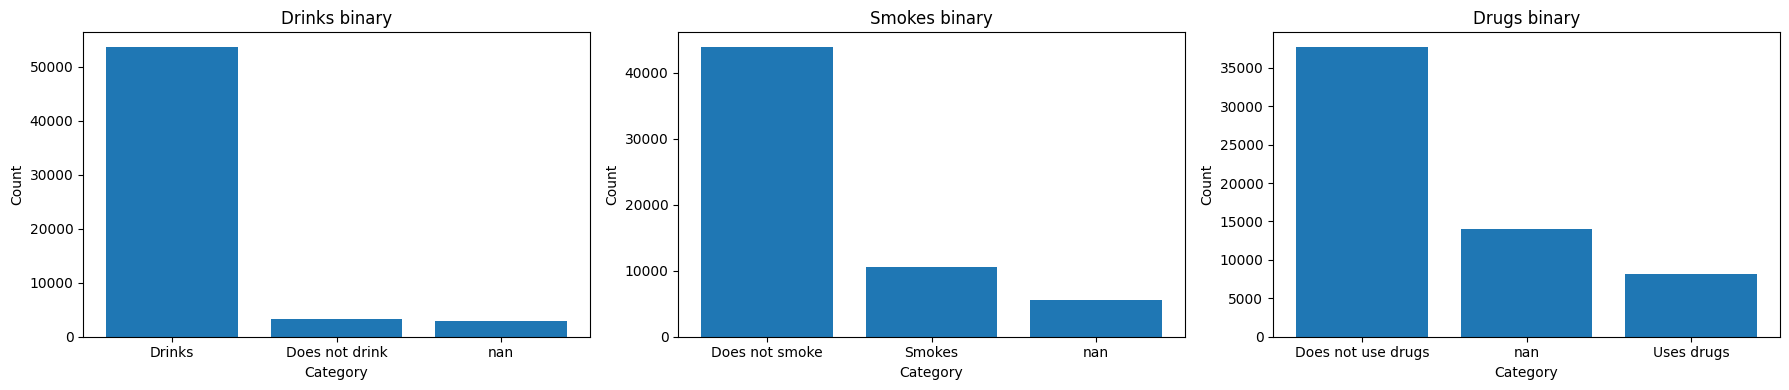

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

drinks_labels = {0: 'Does not drink', 1: 'Drinks'}
smokes_labels = {0: 'Does not smoke', 1: 'Smokes'}
drugs_labels = {0: 'Does not use drugs', 1: 'Uses drugs'}

for ax, col, labels, title in [
    (axes[0], 'drinks_binary', drinks_labels, 'Drinks binary'),
    (axes[1], 'smokes_binary', smokes_labels, 'Smokes binary'),
    (axes[2], 'drugs_binary', drugs_labels, 'Drugs binary')
]:
    counts = df_clean[col].value_counts(dropna=False).rename(index={**labels, np.nan: 'Missing'})
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(title)
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Location features


In [ ]:
location_split = df_clean['location'].str.split(', ', n=1, expand=True)
df_clean['city'] = location_split[0]
df_clean['state'] = location_split[1]

print('Unique cities:', df_clean['city'].nunique(dropna=True))
print('Unique states:', df_clean['state'].nunique(dropna=True))

df_clean[['location', 'city', 'state']].head()


Unique cities: 198
Unique states: 41


,location,city,state
0,"south san francisco, california",south san francisco,california
1,"oakland, california",oakland,california
2,"san francisco, california",san francisco,california
3,"berkeley, california",berkeley,california
4,"san francisco, california",san francisco,california


## Engineering variables



In [ ]:
# A. Activity / visibility proxies
# People who are more recently online and have fuller profiles can be treated as more likely to create edges.
reference_time = df_clean['last_online_dt'].max()

df_clean['days_since_online'] = (reference_time - df_clean['last_online_dt']).dt.days

# Smaller values mean more recent activity.
# Convert this into a bounded activity score.
df_clean['activity_score'] = 1 / (1 + df_clean['days_since_online'].fillna(df_clean['days_since_online'].median()))

# Normalize essay effort and combine it with recency.
df_clean['essay_effort_score'] = (
    df_clean['total_essay_chars'] / df_clean['total_essay_chars'].max()).fillna(0)

df_clean['profile_completeness_score'] = (
    df_clean[key_cols].notna().mean(axis=1))


### THIS IS TO BE REVIEWED USING A BETTER APPROACH LATER
#### KEY KEY KEY THIS IS NOT ENGINEERED WELL AT ALL, JUST A PROXY FOR NOW
df_clean['hub_score_proxy'] = (
    0.5 * df_clean['activity_score'] +
    0.3 * df_clean['essay_effort_score'] +
    0.2 * df_clean['profile_completeness_score'])

In [ ]:
# B. Simple desirability / filtering variables often used in app simulations
# These do not need moral interpretation; they are only sorting variables for matching rules.
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[18, 24, 29, 34, 39, 49, 80],
    labels=['18-24', '25-29', '30-34', '35-39', '40-49', '50+'],
    include_lowest=True)


### TO DECIDE WHETHER TO INCLUDE INCOME CONSIDERING A LOT OF MISSING VARIABLES

df_clean['income_group'] = pd.cut(
    df_clean['income'],
    bins=[0, 30000, 60000, 100000, 200000, np.inf],
    labels=['low', 'lower_mid', 'upper_mid', 'high', 'very_high'])

In [ ]:
# C. Lifestyle / risk proxies for later disease-spread experiments
# These are not actual disease states, only behavior categories that may alter transmission probability.
df_clean['substance_risk_flag'] = (
    df_clean['drinks'].isin(['often', 'very often', 'desperately']) |
    df_clean['drugs'].isin(['sometimes', 'often']) |
    df_clean['smokes'].isin(['yes', 'sometimes', 'when drinking'])).astype(int)

In [ ]:
# D. Market segmentation variables for assortative matching
df_clean['orientation_group'] = df_clean['orientation']
df_clean['city_group'] = df_clean['city']
df_clean['education_group'] = df_clean['education']

df_clean[[
    'activity_score', 'essay_effort_score', 'profile_completeness_score',
    'hub_score_proxy', 'age_group', 'income_group', 'substance_risk_flag'
]].head()

,activity_score,essay_effort_score,profile_completeness_score,hub_score_proxy,age_group,income_group,substance_risk_flag
0,0.200000,0.034618,0.857143,0.281814,18-24,NaN,1
1,0.200000,0.019421,0.904762,0.286779,35-39,upper_mid,1
2,0.200000,0.075354,0.666667,0.255939,35-39,NaN,0
3,0.333333,0.006174,0.857143,0.339948,18-24,low,0
4,0.200000,0.009163,0.714286,0.245606,25-29,NaN,0


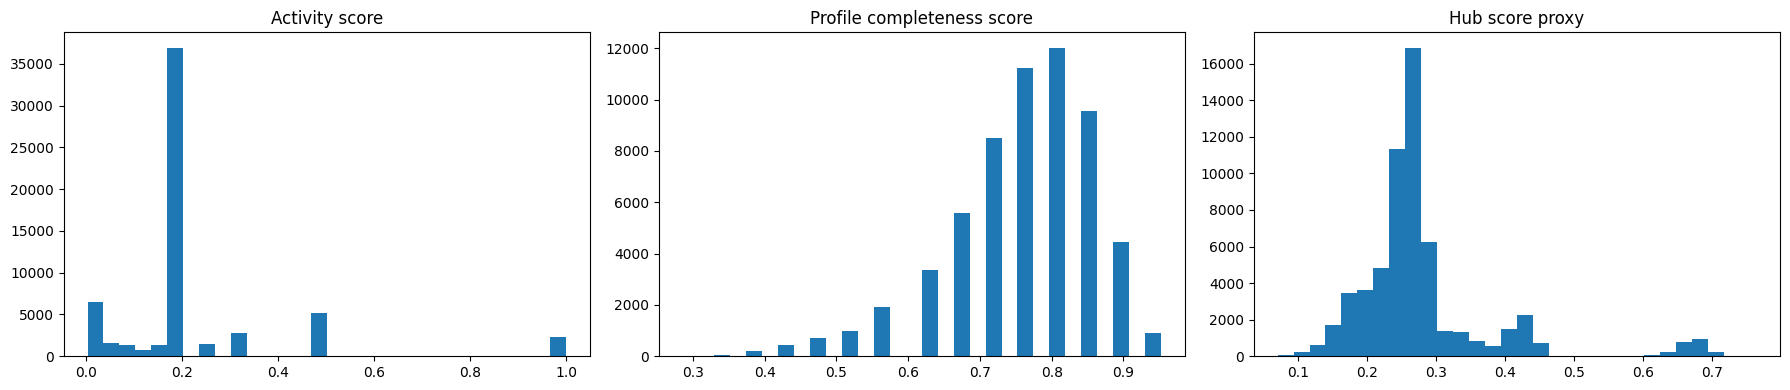

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df_clean['activity_score'].dropna(), bins=30)
axes[0].set_title('Activity score')

axes[1].hist(df_clean['profile_completeness_score'].dropna(), bins=30)
axes[1].set_title('Profile completeness score')

axes[2].hist(df_clean['hub_score_proxy'].dropna(), bins=30)
axes[2].set_title('Hub score proxy')

plt.tight_layout()
plt.show()

# Data preparation

### Encode `sex` and `orientation`

In [ ]:
# sex: m=0, f=1  (NaN preserved)
df_clean['sex_binary'] = df_clean['sex'].map({'m': 0, 'f': 1})

# orientation: three-way numeric for simulation stratification
orientation_map = {'straight': 0, 'bisexual': 1, 'gay': 2}
df_clean['orientation_code'] = df_clean['orientation'].map(orientation_map)

print(df_clean[['sex', 'sex_binary', 'orientation', 'orientation_code']]
      .value_counts(dropna=False).head(20))

sex  sex_binary  orientation  orientation_code
m    0           straight     0                   31073
f    1           straight     0                   20533
m    0           gay          2                    3985
f    1           bisexual     1                    1996
                 gay          2                    1588
m    0           bisexual     1                     771
Name: count, dtype: int64


### Education ordinal scale

In [ ]:
df_clean['education'].value_counts()

,count
education,
graduated from college/university,23959
graduated from masters program,8961
working on college/university,5712
working on masters program,1683
graduated from two-year college,1531
graduated from high school,1428
graduated from ph.d program,1272
graduated from law school,1122
working on two-year college,1074


In [ ]:
education_order = {
    'dropped out of space camp': 0,
    'dropped out of high school': 1,
    'high school': 2,
    'working on high school': 2,
    'dropped out of college/university': 3,
    'some college/university': 3,
    'college/university': 4,
    'working on college/university': 4,
    'dropped out of two-year college': 3,
    'two-year college': 3,
    'working on two-year college': 3,
    'dropped out of masters program': 4,
    'masters program': 5,
    'working on masters program': 5,
    'dropped out of ph.d program': 5,
    'ph.d program': 6,
    'working on ph.d program': 6,
    'dropped out of law school': 5,
    'law school': 6,
    'working on law school': 5,
    'dropped out of med school': 5,
    'med school': 6,
    'working on med school': 5,
    'dropped out of space camp': 0,
    'space camp': 0,
    'working on space camp': 0,
}

df_clean['education_ordinal'] = df_clean['education'].map(education_order)

print('education_ordinal distribution:')
print(df_clean['education_ordinal'].value_counts(dropna=False).sort_index())

education_ordinal distribution:
education_ordinal
0.0     1026
1.0      102
2.0      183
3.0     2482
4.0     6653
5.0     2457
6.0     1039
NaN    46004
Name: count, dtype: int64


### `body_type` to 3 groups

In [ ]:
body_map = {
    'thin':          'lean',
    'skinny':        'lean',
    'fit':           'average',
    'athletic':      'average',
    'average':       'average',
    'a little extra':'heavy',
    'curvy':         'heavy',
    'full figured':  'heavy',
    'overweight':    'heavy',
    'jacked':        'average',
    'used up':       'average',
    'rather not say': np.nan,
}

df_clean['body_type_group'] = df_clean['body_type'].map(body_map)

print(df_clean['body_type_group'].value_counts(dropna=False))

body_type_group
average    39958
heavy       8006
lean        6488
NaN         5494
Name: count, dtype: int64


### Assortativity weight matrix (literature-based)


In [ ]:
# ── Assortativity weight matrix skeleton ────────────────────────────────────
# Each sub-function returns a probability MULTIPLIER (0 to 1).
# Final match probability = product of all multipliers × base_rate.
# Plug your literature values into each function.

BASE_MATCH_RATE = 0.05   # replace with empirical baseline from your paper

def age_homophily_weight(age_i, age_j):
    """Probability weight based on age difference.
    Literature: match probability declines with |age_i - age_j|.
    Placeholder: Gaussian decay with sigma=5 years."""
    if pd.isna(age_i) or pd.isna(age_j):
        return 1.0  # no penalty for unknown
    diff = abs(age_i - age_j)
    return float(np.exp(-0.5 * (diff / 5) ** 2))

def education_homophily_weight(edu_i, edu_j):
    """Same-education-level bonus.
    Replace 1.5 with the OR from your citation."""
    if pd.isna(edu_i) or pd.isna(edu_j):
        return 1.0
    return 1.5 if edu_i == edu_j else 1.0

def substance_risk_weight(risk_i, risk_j):
    """Higher risk users more likely to match each other.
    Replace 2.0 with odds-ratio from your STD/sexual-network literature."""
    if risk_i == 1 and risk_j == 1:
        return 2.0
    if risk_i == 0 and risk_j == 0:
        return 1.0
    return 0.8   # cross-risk-group discount

def compute_match_probability(row_i, row_j):
    """Combine all weights into a single edge probability."""
    p = BASE_MATCH_RATE
    p *= age_homophily_weight(row_i.get('age'), row_j.get('age'))
    p *= education_homophily_weight(row_i.get('education_ordinal'), row_j.get('education_ordinal'))
    p *= substance_risk_weight(row_i.get('substance_risk_flag', 0), row_j.get('substance_risk_flag', 0))
    return min(p, 1.0)   # cap at 1

# Quick smoke test on two synthetic users
user_a = {'age': 28, 'education_ordinal': 4, 'substance_risk_flag': 0}
user_b = {'age': 30, 'education_ordinal': 4, 'substance_risk_flag': 0}
user_c = {'age': 28, 'education_ordinal': 2, 'substance_risk_flag': 1}

print(f'A-B match prob (similar):  {compute_match_probability(user_a, user_b):.4f}')
print(f'A-C match prob (dissimilar): {compute_match_probability(user_a, user_c):.4f}')

A-B match prob (similar):  0.0692
A-C match prob (dissimilar): 0.0400


# Diving Deeper into Exploratory Data Analysis

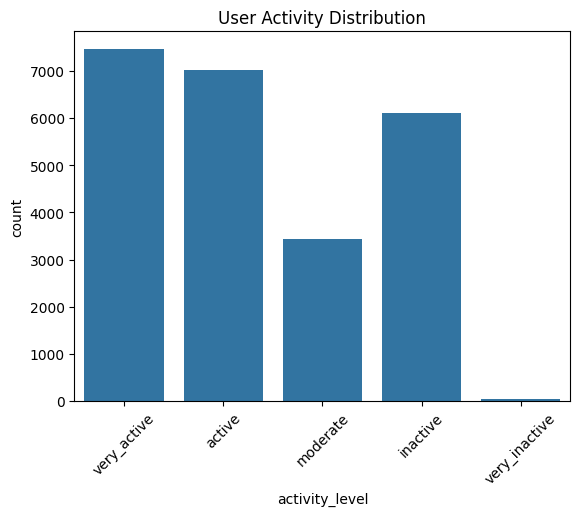

In [ ]:
df['last_online'] = pd.to_datetime(df['last_online'], errors='coerce', utc=True)
latest_date = df['last_online'].max()

df['days_since_online'] = (latest_date - df['last_online']).dt.days

# Activity buckets
df['activity_level'] = pd.cut(df['days_since_online'],
                              bins=[-1, 1, 7, 30, 365, 5000],
                              labels=['very_active', 'active', 'moderate', 'inactive', 'very_inactive'])


sns.countplot(x='activity_level', data=df)
plt.xticks(rotation=45)
plt.title("User Activity Distribution")
plt.show()

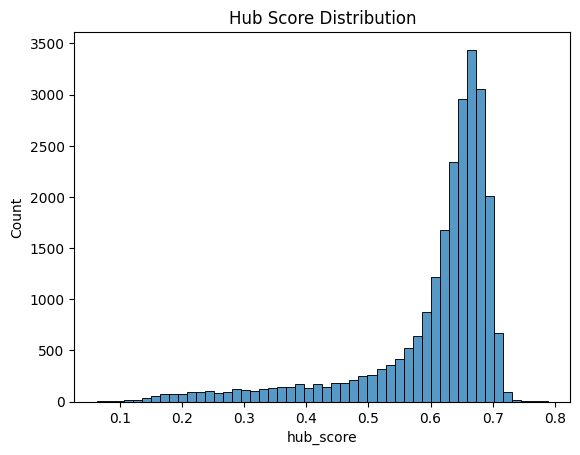

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean['norm_activity'] = 1 - scaler.fit_transform(df_clean[['days_since_online']])
df_clean['norm_essay'] = scaler.fit_transform(df_clean[['total_essay_chars']])       # ← correct name
df_clean['norm_profile'] = scaler.fit_transform(df_clean[['profile_completeness_score']])  # ← correct name

df_clean['hub_score'] = (
    0.5 * df_clean['norm_activity'] +
    0.3 * df_clean['norm_essay'] +
    0.2 * df_clean['norm_profile'])

sns.histplot(df_clean['hub_score'], bins=50)
plt.title("Hub Score Distribution")
plt.show()

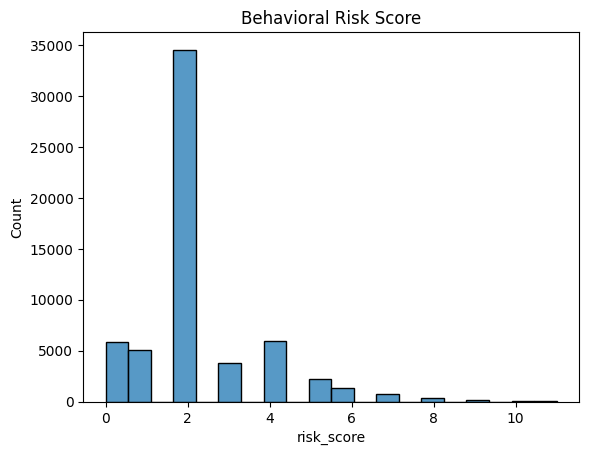

In [ ]:
risk_map = {
    'drinks': {'not at all':0, 'rarely':1, 'socially':2, 'often':3, 'very often':4},
    'drugs': {'never':0, 'sometimes':2, 'often':4},
    'smokes': {'no':0, 'sometimes':2, 'yes':3}
}

for col in ['drinks','drugs','smokes']:
    df[col + '_risk'] = df[col].map(risk_map[col])

df['risk_score'] = df[['drinks_risk','drugs_risk','smokes_risk']].sum(axis=1)

sns.histplot(df['risk_score'], bins=20)
plt.title("Behavioral Risk Score")
plt.show()

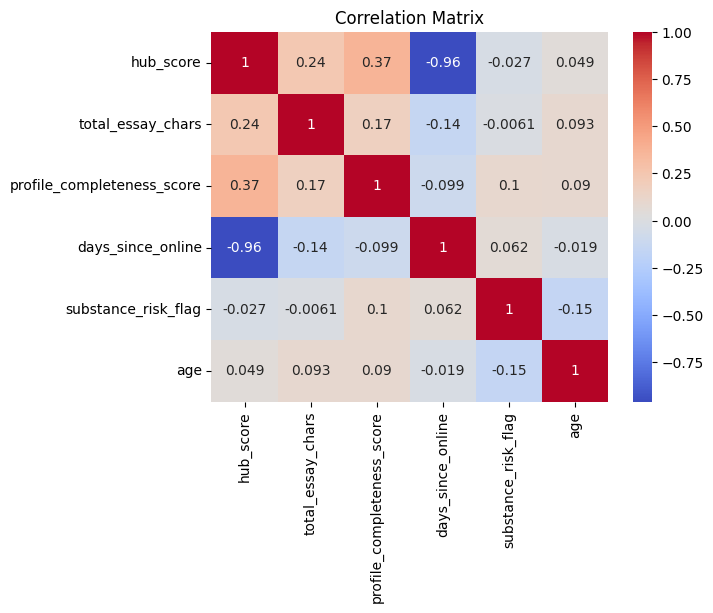

In [ ]:
corr_cols = ['hub_score', 'total_essay_chars', 'profile_completeness_score', 'days_since_online', 'substance_risk_flag', 'age']

corr = df_clean[corr_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()